In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('consumption_temp.csv')
df.head()

,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
1,2022-04-07 21:00:00,oslo,4.092830,1.0
2,2022-04-07 21:00:00,stavanger,2.057858,1.3
3,2022-04-07 21:00:00,tromsø,1.246582,-3.9
4,2022-04-07 21:00:00,trondheim,1.970098,-2.8


In [11]:
df['time'] = pd.to_datetime(df['time'])
print(df.info())
print(df.isnull().sum())
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49494 entries, 0 to 49493
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time         49494 non-null  datetime64[ns]
 1   location     49494 non-null  object        
 2   consumption  49494 non-null  float64       
 3   temperature  49494 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 1.5+ MB
None
time           0
location       0
consumption    0
temperature    0
dtype: int64

Number of duplicate rows: 0


In [12]:
# count unique locations
print(f"Number of unique locations: {df['location'].nunique()}")

# print unique values in 'location' column
print(f"Unique locations: {df['location'].unique()}")

# create subsets for each location
df_bergen = df[df['location'] == 'bergen']
df_oslo = df[df['location'] == 'oslo']
df_stavanger = df[df['location'] == 'stavanger']
df_tromso = df[df['location'] == 'tromsø']
df_trondheim = df[df['location'] == 'trondheim']
df_helsingfors = df[df['location'] == 'helsingfors']

# show the history range, first datetime to last datetime for each location
print(f"Bergen date range: {df_bergen['time'].min()} to {df_bergen['time'].max()}")
print(f"Oslo date range: {df_oslo['time'].min()} to {df_oslo['time'].max()}")
print(f"Stavanger date range: {df_stavanger['time'].min()} to {df_stavanger['time'].max()}")
print(f"Tromsø date range: {df_tromso['time'].min()} to {df_tromso['time'].max()}")
print(f"Trondheim date range: {df_trondheim['time'].min()} to {df_trondheim['time'].max()}")
print(f"Helsingfors date range: {df_helsingfors['time'].min()} to {df_helsingfors['time'].max()}")

print("(ex.) Bergen history length:", len(df_bergen))
df_bergen.head()

Number of unique locations: 6
Unique locations: ['bergen' 'oslo' 'stavanger' 'tromsø' 'trondheim' 'helsingfors']
Bergen date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Oslo date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Stavanger date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Tromsø date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Trondheim date range: 2022-04-07 21:00:00 to 2023-04-02 21:00:00
Helsingfors date range: 2022-07-14 21:00:00 to 2023-04-02 21:00:00
(ex.) Bergen history length: 8641


,time,location,consumption,temperature
0,2022-04-07 21:00:00,bergen,1.113325,-0.3
5,2022-04-07 22:00:00,bergen,1.050327,0.0
10,2022-04-07 23:00:00,bergen,1.008794,-0.5
15,2022-04-08 00:00:00,bergen,0.984202,-1.1
20,2022-04-08 01:00:00,bergen,0.950335,-0.7


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- Plot style ----------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.35,
    "grid.linewidth": 0.7,
})

# ---------- Collect dataframes ----------
location_dfs = {
    "Bergen": df_bergen.copy(),
    "Oslo": df_oslo.copy(),
    "Stavanger": df_stavanger.copy(),
    "Tromsø": df_tromso.copy(),
    "Trondheim": df_trondheim.copy(),
    "Helsingfors": df_helsingfors.copy(),
}

# Ensure datetime dtype and add location name
for loc, d in location_dfs.items():
    d["time"] = pd.to_datetime(d["time"])
    d["location"] = loc

# Long dataframe for easier plotting
df_long = pd.concat(location_dfs.values(), ignore_index=True)

# Consistent color mapping across all figures
location_colors = {
    "Bergen":      "#08306b",  # very dark blue
    "Oslo":        "#08519c",  # dark blue
    "Stavanger":   "#2171b5",  # medium-dark blue
    "Tromsø":      "#4292c6",  # medium blue
    "Trondheim":   "#6baed6",  # light-medium blue
    "Helsingfors": "#9ecae1",  # light blue
}
pred_colors = {
    PREDICTION_COLOR = "#b22222"      # firebrick
    BASELINE_COLOR = "#7f7f7f"        # gray
    ROLLING_MEAN_COLOR = "#222222"    # near black
    REFERENCE_LINE_COLOR = "#666666"
}
# Monthly tick formatting
month_locator = mdates.MonthLocator(interval=2)
month_fmt = mdates.DateFormatter("%b %Y")

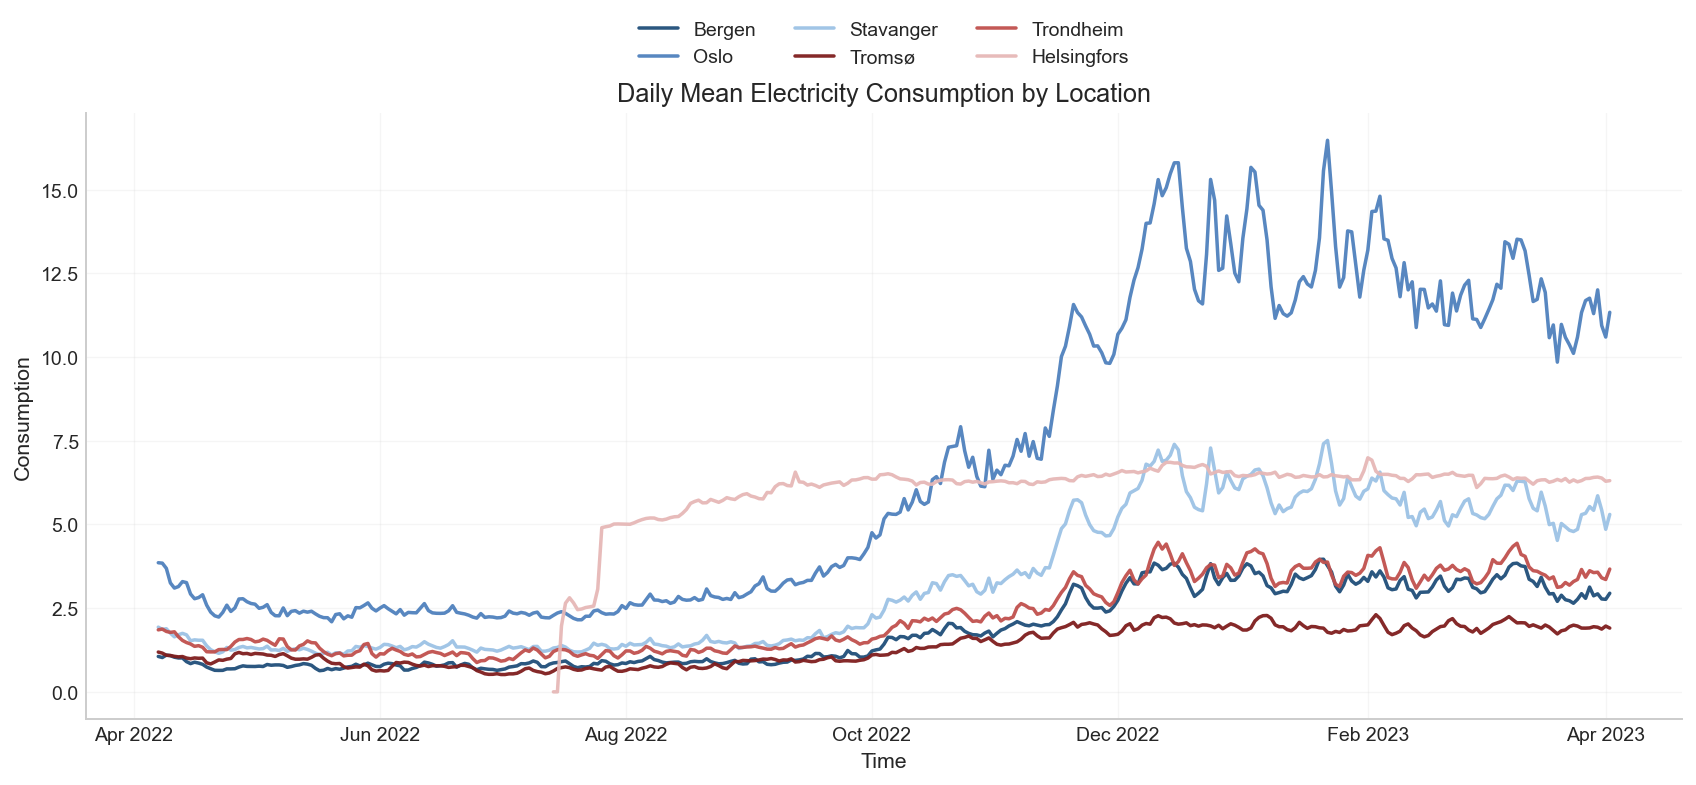

In [14]:
# Daily mean consumption for a cleaner overview figure
daily_consumption = (
    df_long
    .groupby(["location", pd.Grouper(key="time", freq="D")], as_index=False)["consumption"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)

for loc in location_dfs.keys():
    sub = daily_consumption[daily_consumption["location"] == loc]
    ax.plot(
        sub["time"],
        sub["consumption"],
        label=loc,
        color=location_colors[loc],
        linewidth=1.8,
        alpha=0.95
    )

ax.set_title("Daily Mean Electricity Consumption by Location")
ax.set_xlabel("Time")
ax.set_ylabel("Consumption")
ax.xaxis.set_major_locator(month_locator)
ax.xaxis.set_major_formatter(month_fmt)
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

plt.show()

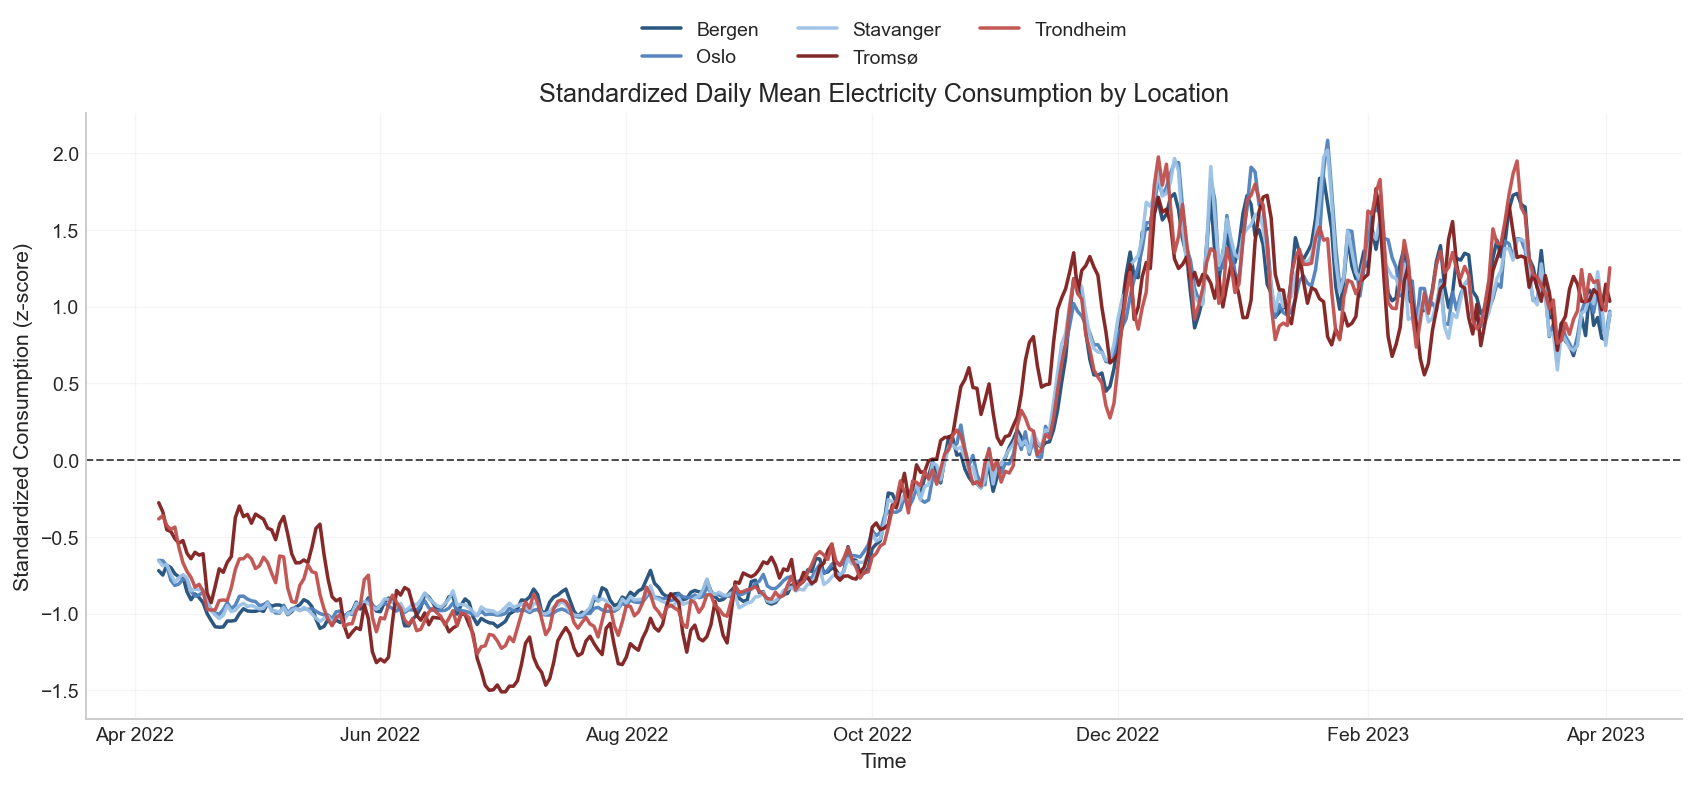

In [15]:
# Standardize daily mean consumption within each location
daily_std = daily_consumption.copy()
daily_std["consumption_z"] = (
    daily_std.groupby("location")["consumption"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

# If you want to exclude Helsingfors to match the common five-location analysis:
locations_std = ["Bergen", "Oslo", "Stavanger", "Tromsø", "Trondheim"]

fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)

for loc in locations_std:
    sub = daily_std[daily_std["location"] == loc]
    ax.plot(
        sub["time"],
        sub["consumption_z"],
        label=loc,
        color=location_colors[loc],
        linewidth=1.8,
        alpha=0.95
    )

ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
ax.set_title("Standardized Daily Mean Electricity Consumption by Location")
ax.set_xlabel("Time")
ax.set_ylabel("Standardized Consumption (z-score)")
ax.xaxis.set_major_locator(month_locator)
ax.xaxis.set_major_formatter(month_fmt)
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18))

plt.show()

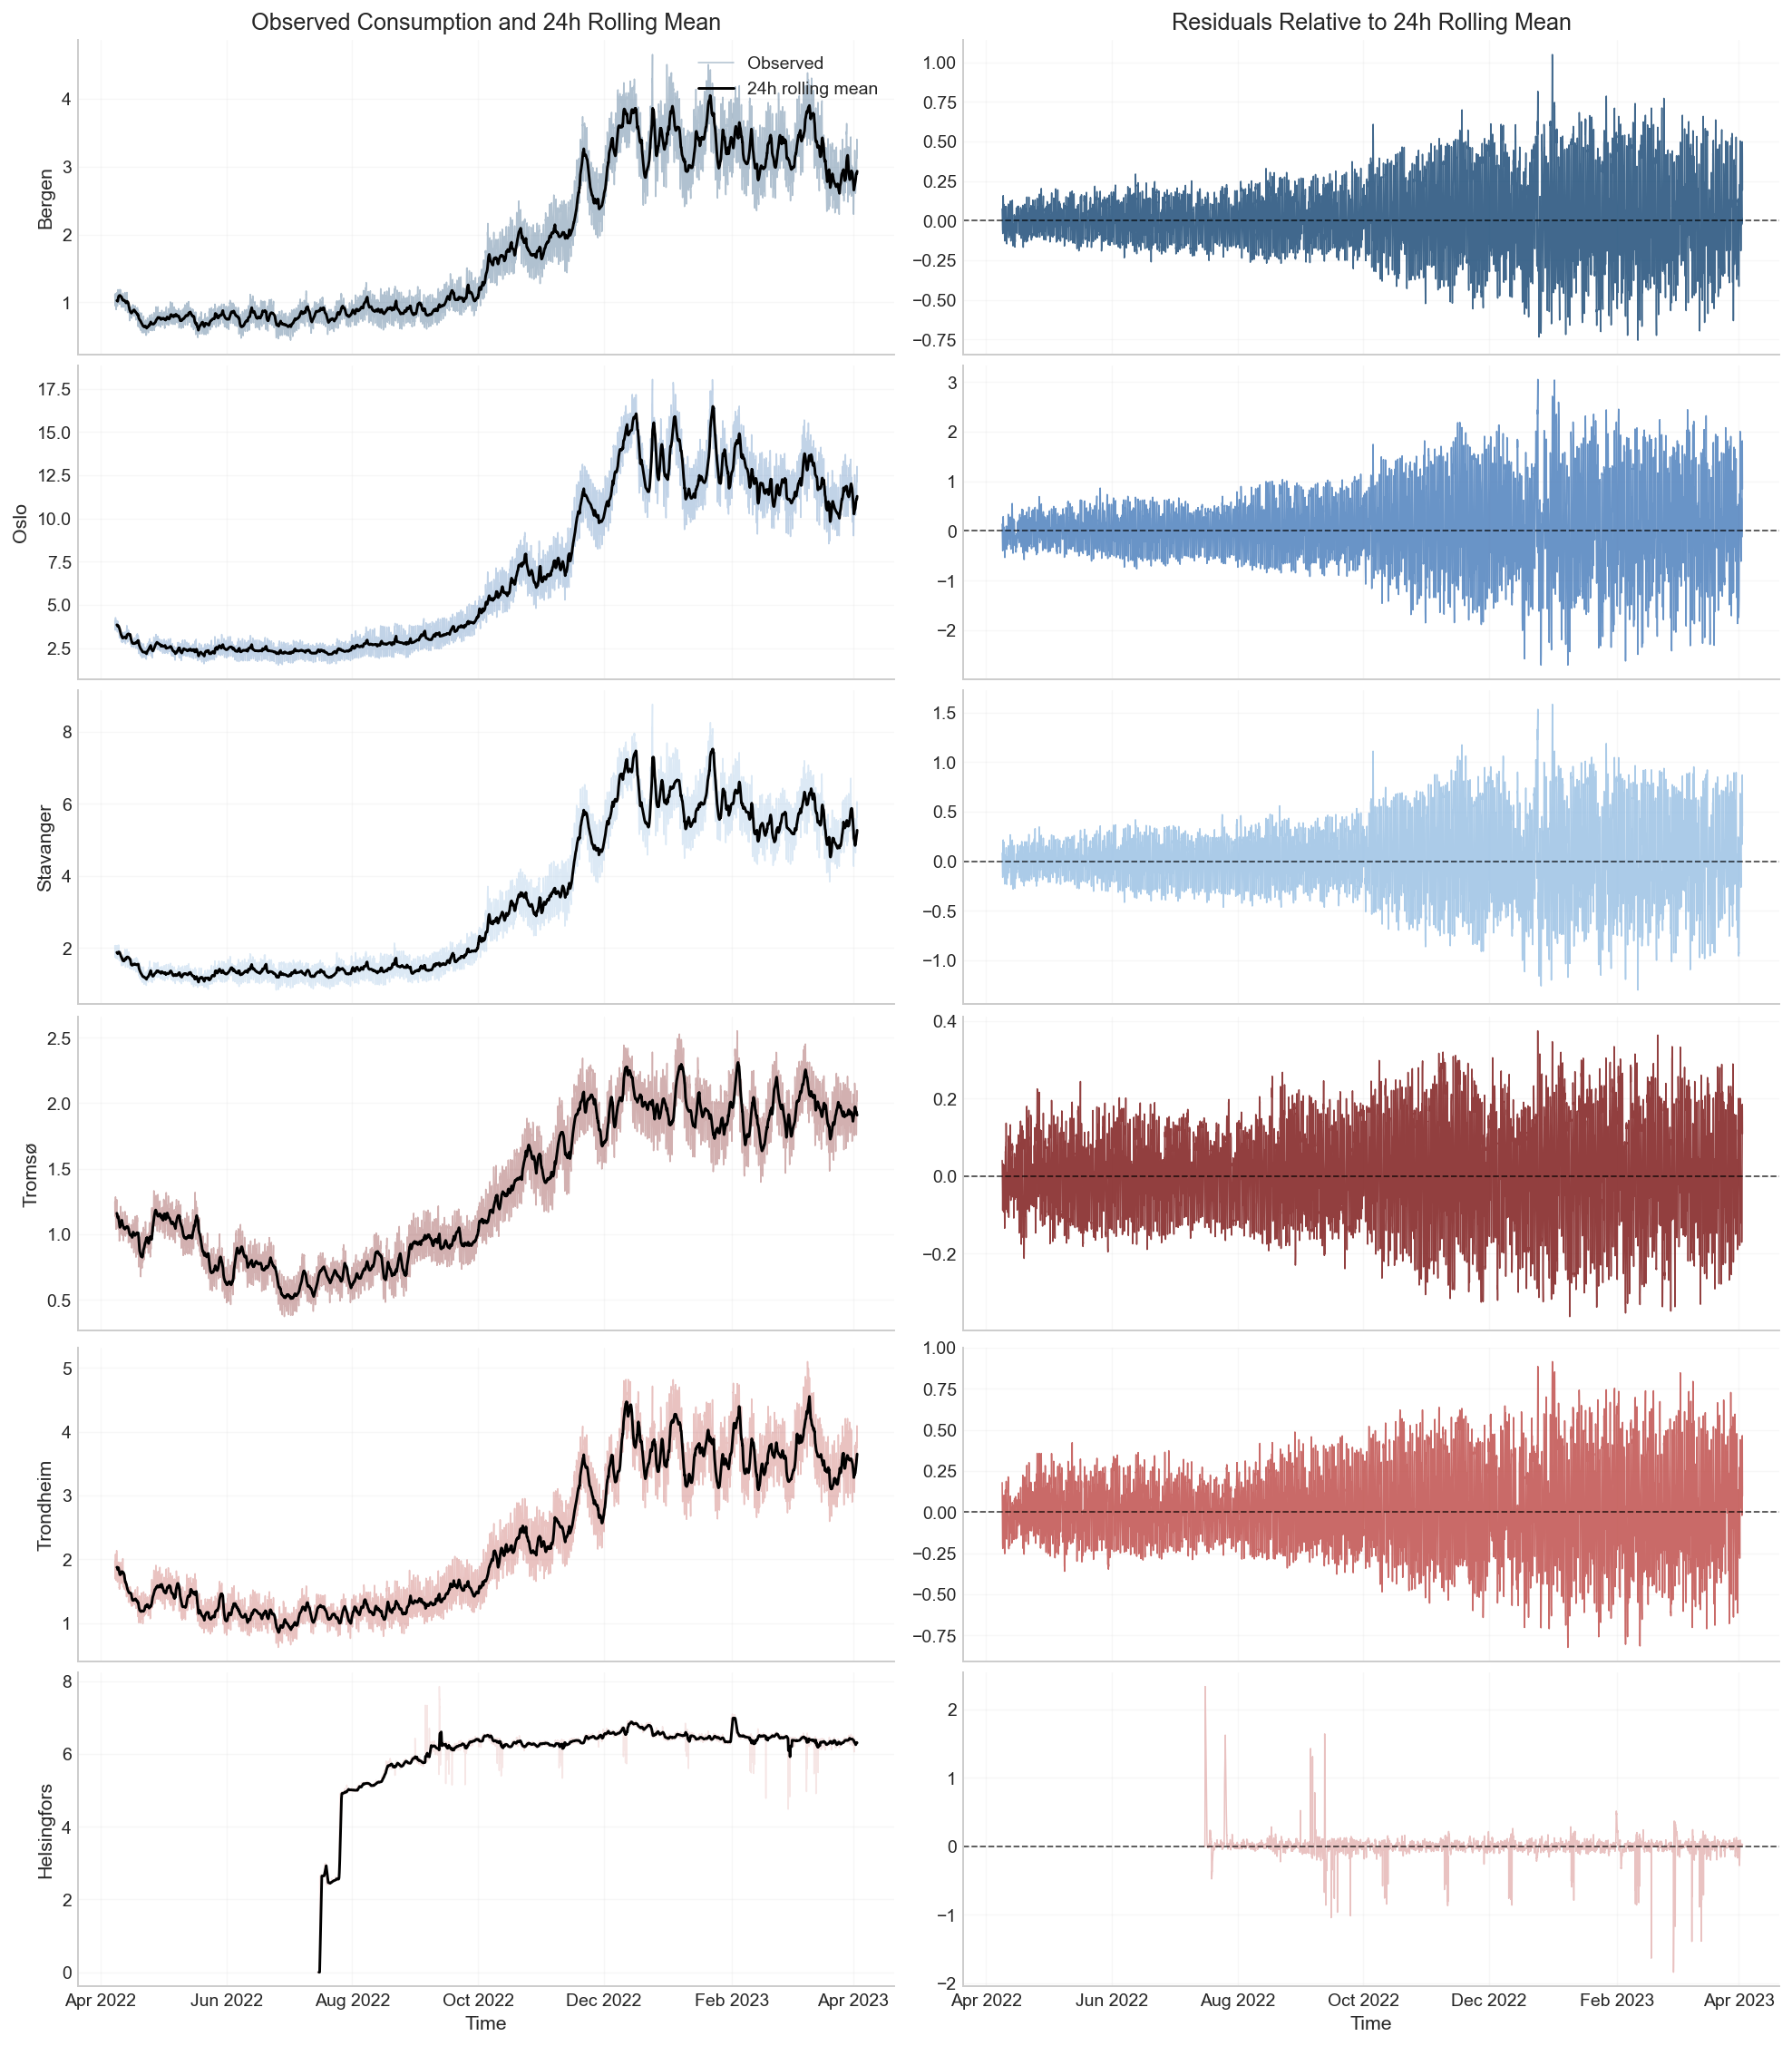

In [16]:
# Multi-panel figure: actual vs 24h rolling mean, plus residuals
locations = ["Bergen", "Oslo", "Stavanger", "Tromsø", "Trondheim", "Helsingfors"]

fig, axes = plt.subplots(
    nrows=len(locations),
    ncols=2,
    figsize=(14, 16),
    sharex=True,
    constrained_layout=True
)

for i, loc in enumerate(locations):
    d = location_dfs[loc].copy().sort_values("time")
    d["rolling_mean_24h"] = d["consumption"].rolling(window=24, min_periods=24).mean()
    d["residual_24h"] = d["consumption"] - d["rolling_mean_24h"]

    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    # Actual + rolling mean
    ax_left.plot(
        d["time"],
        d["consumption"],
        color=location_colors[loc],
        linewidth=0.8,
        alpha=0.35,
        label="Observed"
    )
    ax_left.plot(
        d["time"],
        d["rolling_mean_24h"],
        color="black",
        linewidth=1.5,
        label="24h rolling mean"
    )
    ax_left.set_ylabel(loc)
    ax_left.grid(True, alpha=0.2)

    # Residuals
    ax_right.plot(
        d["time"],
        d["residual_24h"],
        color=location_colors[loc],
        linewidth=0.8,
        alpha=0.85
    )
    ax_right.axhline(0, color="black", linestyle="--", linewidth=0.9, alpha=0.7)
    ax_right.grid(True, alpha=0.2)

# Column titles
axes[0, 0].set_title("Observed Consumption and 24h Rolling Mean")
axes[0, 1].set_title("Residuals Relative to 24h Rolling Mean")

# X-axis formatting on bottom row
for ax in axes[-1, :]:
    ax.xaxis.set_major_locator(month_locator)
    ax.xaxis.set_major_formatter(month_fmt)
    ax.set_xlabel("Time")

# Add one legend only
axes[0, 0].legend(frameon=False, loc="upper right")

plt.show()